 **PROJECT 2**





Business Context: Develop a model for predicting fraudulent transactions for a financial
company and use insights from the model to develop an actionable plan.
1. Data cleaning including missing values, outliers and multi-collinearity.
2. Perform Detailed Data Analysis
3. Perform EDA
4. What are the key factors that predict fraudulent customer?

Dataset columns description:

 step - maps a unit of time in the real world. In this case 1 step is 1 hour of time.
Total steps 744 (30 days simulation).

 type - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.
 amount - amount of the transaction in local currency.

 nameOrig - customer who started the transaction

 oldbalanceOrg - initial balance before the transaction

 newbalanceOrig - new balance after the transaction

 nameDest - customer who is the recipient of the transaction

 oldbalanceDest - initial balance recipient before the transaction. Note that there
is not information for customers that start with M (Merchants).

 newbalanceDest - new balance recipient after the transaction. Note that there is
not information for customers that start with M (Merchants).

 isFraud - This is the transactions made by the fraudulent agents inside the
simulation. In this specific dataset the fraudulent behavior of the agents aims to
profit by taking control or customers accounts and try to empty the funds by
transferring to another account and then cashing out of the system.

 isFlaggedFraud - The business model aims to control massive transfers from one
account to another and flags illegal attempts. An illegal attempt in this dataset is
an attempt to transfer more than 200.000 in a single transaction.

# ANSWERS:

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
data=pd.read_csv('/content/Fraud (1).csv')
data

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


# BASIC CHECKS

In [ ]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
data.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [ ]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
data.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


In [ ]:
data.shape

(6362620, 11)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


# DATA PREPROCESSING

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


# DESCRIPTION:


* Rows: 6362620

* Columns : 11

* Target Variable: isFraud

* Classification Type: Binary Classification

* Transaction Types:

    * CASH_OUT
    * PAYMENT
    * CASH_IN
    * TRANSFER
    * DEBIT

Fraud Distribution:

 * Fraudulent transactions account for only a very small percentage of the dataset.

 * The dataset is highly imbalanced.

  * Fraudulent transactions often involve accounts where the sender's balance is almost completely emptied.

  * Destination balances frequently change significantly after fraudulent transfers.


Target Column: Class

   * 0 = Genuine Transaction

   * 1 = Fraud Transaction

Features:
Time

V1–V28 (PCA transformed features)

Amount

Class

| Column         | Description                         |
| -------------- | ----------------------------------- |
| step           | Time step                           |
| type           | Payment type                        |
| amount         | Transaction amount                  |
| nameOrig       | Sender ID                           |
| oldbalanceOrg  | Sender balance before transaction   |
| newbalanceOrig | Sender balance after transaction    |
| nameDest       | Receiver ID                         |
| oldbalanceDest | Receiver balance before transaction |
| newbalanceDest | Receiver balance after transaction  |
| isFraud        | Target (0/1)                        |
| isFlaggedFraud | Flagged transaction                 |


In [ ]:
s=pd.DataFrame(data.isnull().sum())

In [ ]:
s

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
s[s[0]>0]

,0


# HANDLING MISSING VALUES

In [ ]:
num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest','isFraud','isFlaggedFraud']

for col in num_cols:
    data[col].fillna(data[col].median(), inplace=True)

In [ ]:
cat_cols = ['nameOrig', 'nameDest']

for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

In [ ]:
data.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
for col in data.columns:
    if data[col].nunique() == 1:
        print(col)

In [ ]:
data.isnull().sum()[data.isnull().sum()>0]

,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
duplicates = data[data.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [step, type, amount, nameOrig, oldbalanceOrg, newbalanceOrig, nameDest, oldbalanceDest, newbalanceDest, isFraud, isFlaggedFraud]
Index: []


In [ ]:
data = data.drop_duplicates()

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.shape

(6362620, 11)

# Statistical Analysis:

* The dataset contains transaction records with both numerical and categorical features used to identify fraudulent transactions.

* Numerical features include transaction amount and account balances, while categorical features include transaction type.

* The amount column typically shows a wide range of values with a high standard deviation, indicating that transaction amounts vary significantly.

* The distribution is usually positively skewed, meaning most transactions are of smaller amounts, with a few very large transactions.


* Features such as oldbalanceOrg, newbalanceOrig, oldbalanceDest, and newbalanceDest exhibit considerable variability.

* These variables are often right-skewed due to a small number of accounts with very high balances.

* The target variable isFraud is generally highly imbalanced, with legitimate transactions (0) greatly outnumbering fraudulent transactions (1).

* This imbalance should be considered during model training and evaluation.

* The mean, median, and mode differ for several numerical variables, suggesting that some features are skewed rather than normally distributed.

* The median is often a better measure of central tendency for skewed data.

* Standard deviation and variance indicate that transaction amounts and account balances have high variability.

* Large differences between minimum and maximum values suggest the presence of extreme observations.

* The statistical summary and box plots may reveal outliers in transaction amounts and balance-related features.

* These outliers may represent genuine high-value transactions or potentially suspicious activity and should be analyzed carefully rather than removed automatically.

* Some balance-related features are moderately to strongly correlated because they represent account balances before and after transactions.

* Correlation analysis helps identify redundant features and understand relationships among variables.


* In transaction datasets where a large number of small transactions coexist with a small number of very large transactions.


* The statistical analysis shows that the dataset contains highly variable, skewed, and imbalanced transaction data. Proper preprocessing, feature engineering, and the use of evaluation metrics suitable for imbalanced classification (such as precision, recall, F1-score, and ROC-AUC) are essential for building an effective fraud detection model.

In [ ]:
data = data.drop('isFlaggedFraud', axis=1)

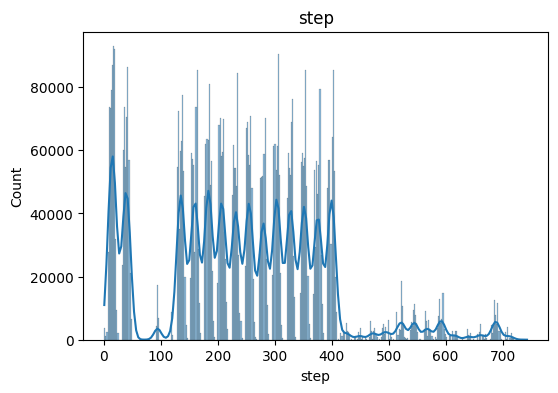

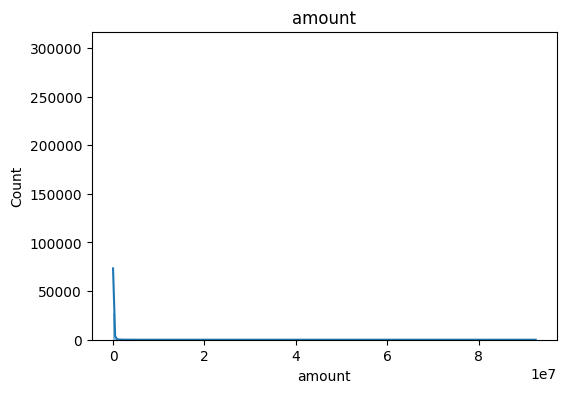

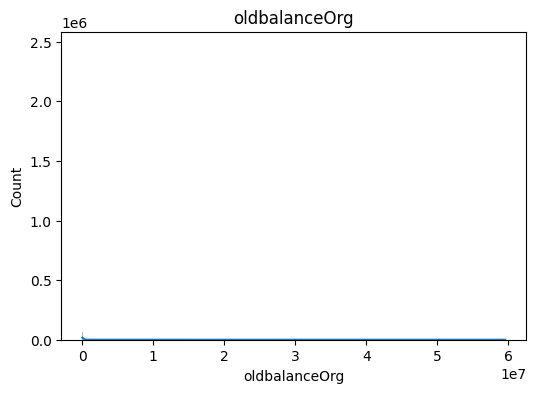

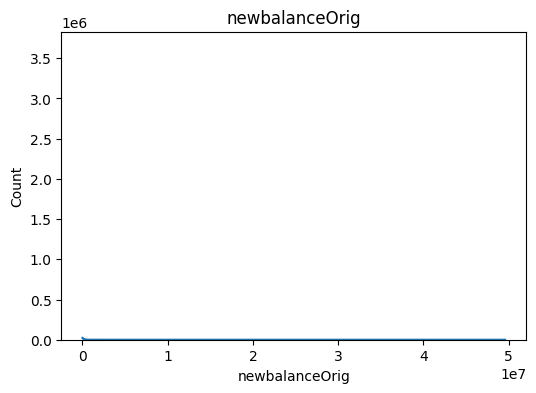

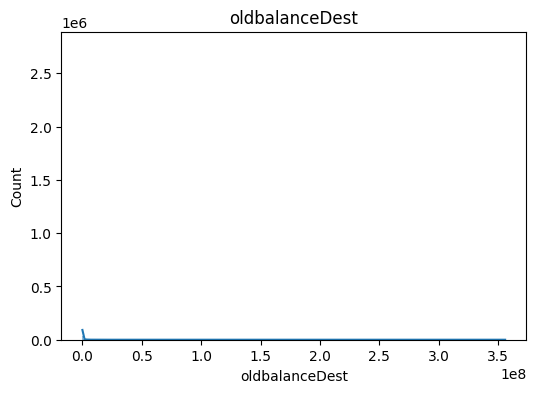

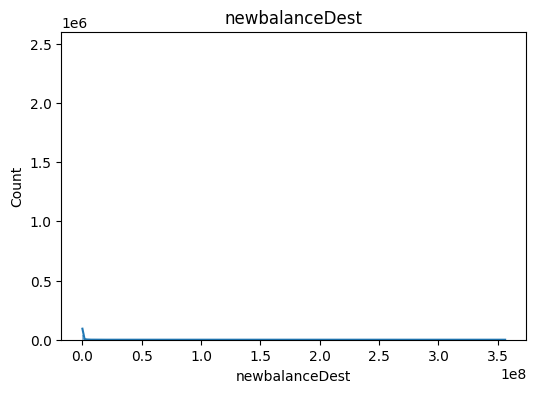

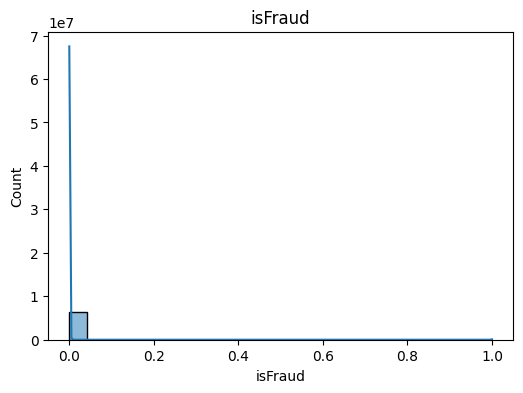

In [ ]:
num_col = data.select_dtypes(include=['int64','float64']).columns

for col in num_col:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True)
    plt.title(col)
    plt.show()

In [ ]:
data.skew(numeric_only=True)

,0
step,0.375177
amount,30.993949
oldbalanceOrg,5.249136
newbalanceOrig,5.176884
oldbalanceDest,19.921758
newbalanceDest,19.352302
isFraud,27.779538


positively skewed distributions in columns:

* amount

* oldbalanceOrg

* newbalanceOrig

* oldbalanceDest

* newbalanceDest

# BOX PLOT FOR OUTLIER HANDLING

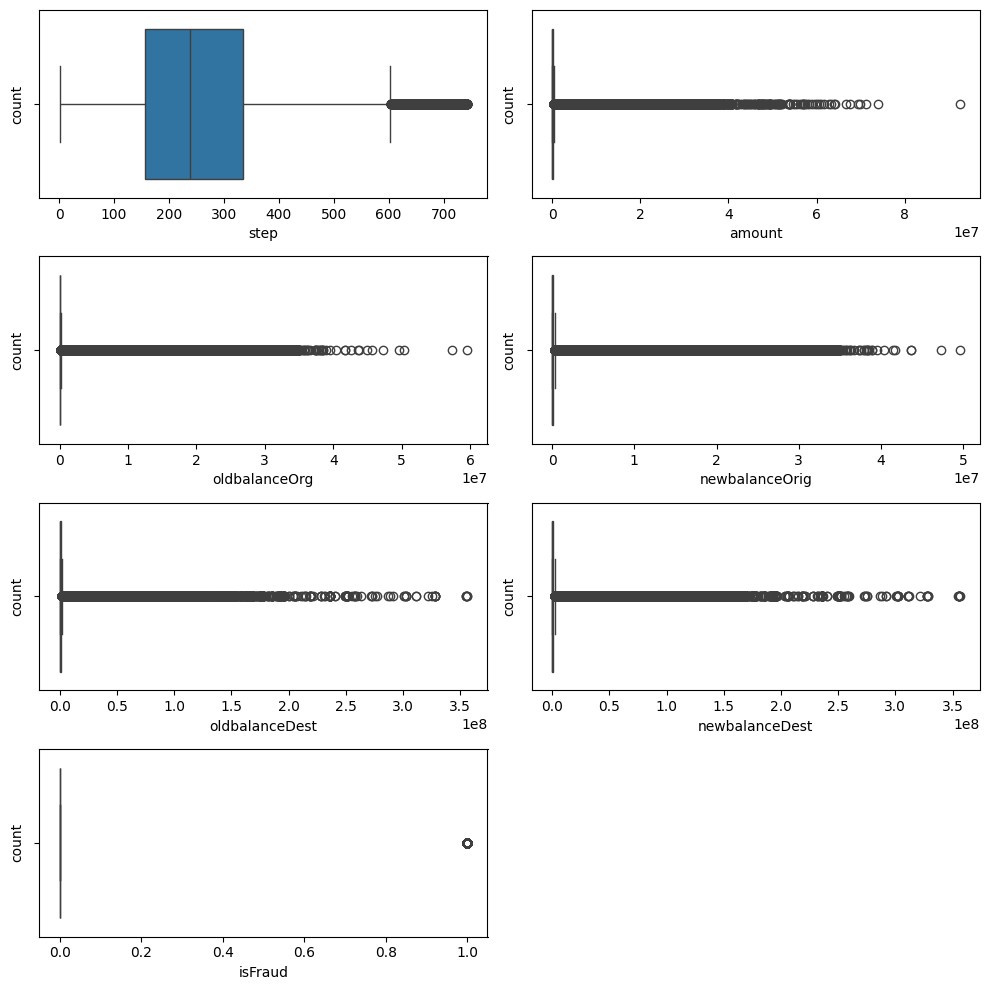

In [ ]:
num_data=['step','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','isFraud',]
plt.figure(figsize=(10,10),facecolor='white')
plotnumber=1
for i in num_data:
    if plotnumber<=8:
        ax=plt.subplot(4,2,plotnumber)
        sns.boxplot(x=data[i])
        plt.xlabel(i,fontsize=10)
        plt.ylabel('count',fontsize=10)
    plotnumber+=1
plt.tight_layout()

# OUTLIERS HANDLING:

In [ ]:
for i in num_data:
    print(i)

    Q1=data[i].quantile(0.25)
    print('lower_limit',Q1)
    Q3=data[i].quantile(0.75)
    print('upper_limit',Q3)

    IQR=Q3-Q1
    print(IQR)

    lower_limit=Q1-1.5*IQR
    print('lower_limit',lower_limit)
    upper_limit=Q3+1.5*IQR
    print('upper_limit',upper_limit)

    lower_outlier=len(data[data[i]<lower_limit])
    upper_outlier=len(data[data[i]>upper_limit])

    result=(lower_outlier + upper_outlier)/len(data)
    print(result)

    if result<0.05:
        data.loc[data[i] < lower_limit, i] = data[i].median()
        data.loc[data[i] > upper_limit, i] = data[i].median()
        print(data[i].median())
    else:
        print('outlier is not handled in',i)
    print('****************************************************')

step
lower_limit 156.0
upper_limit 335.0
179.0
lower_limit -112.5
upper_limit 603.5
0.016139263385209237
239.0
****************************************************
amount
lower_limit 13389.57
upper_limit 208721.4775
195331.9075
lower_limit -279608.29125
upper_limit 501719.33875
0.05313502928039078
outlier is not handled in amount
****************************************************
oldbalanceOrg
lower_limit 0.0
upper_limit 107315.175
107315.175
lower_limit -160972.7625
upper_limit 268287.9375
0.17485045468690572
outlier is not handled in oldbalanceOrg
****************************************************
newbalanceOrig
lower_limit 0.0
upper_limit 144258.41
144258.41
lower_limit -216387.615
upper_limit 360646.025
0.16555931361608897
outlier is not handled in newbalanceOrig
****************************************************
oldbalanceDest
lower_limit 0.0
upper_limit 943036.7075
943036.7075
lower_limit -1414555.06125
upper_limit 2357591.76875
0.12355523353587045
outlier is not handled in

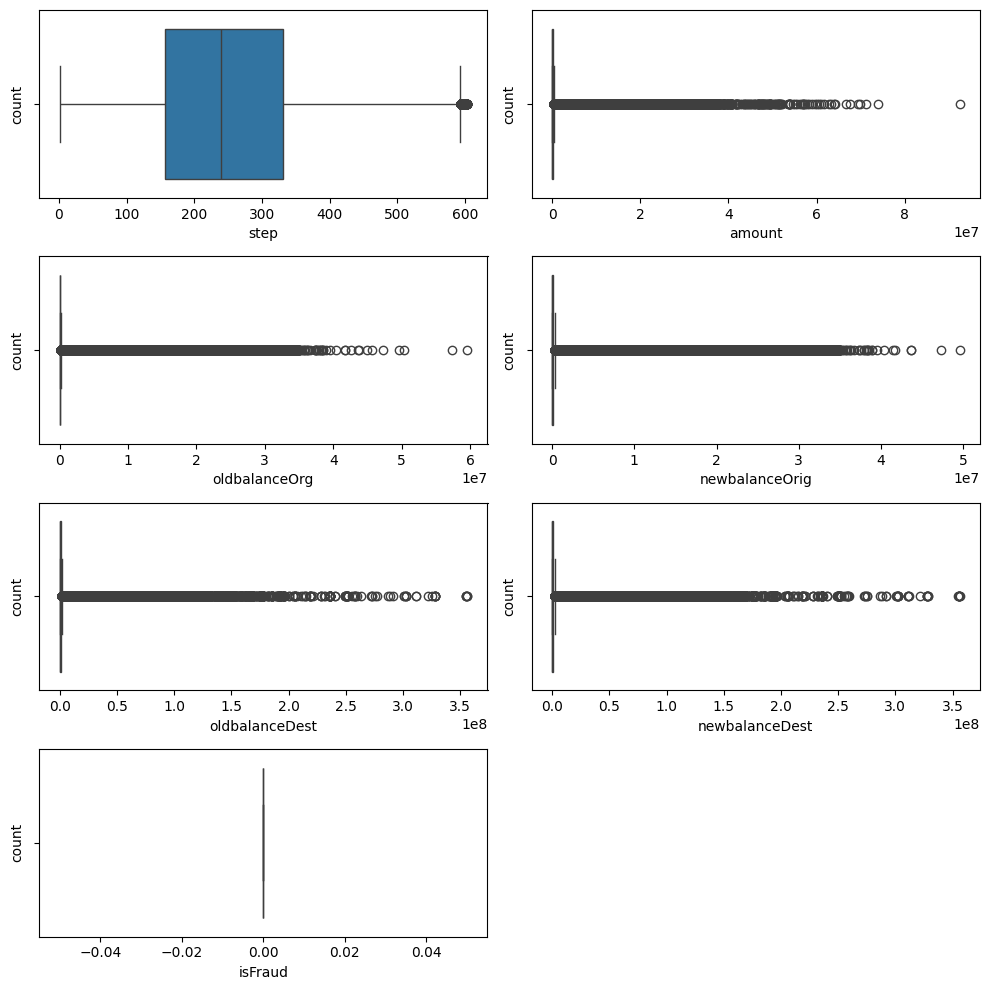

In [ ]:
plt.figure(figsize=(10,10),facecolor='white')
plotnumber=1
for i in num_data:
    if plotnumber<=8:
        ax=plt.subplot(4,2,plotnumber)
        sns.boxplot(x=data[i])
        plt.xlabel(i,fontsize=10)
        plt.ylabel('count',fontsize=10)
    plotnumber+=1
plt.tight_layout()

# OUTLIERS ARE  NOT HANDLED IN COLUMNS:


* amount

* oldbalanceOrg

* newbalanceOrig

* oldbalanceDest

* newbalanceDest




# OUTLIERS ARE  HANDLED IN COLUMNS:


* step

* isFraud




For a normal transaction:

newbalanceOrig=oldbalanceOrg−amount
	​

amount=oldbalanceOrg−newbalanceOrig
	​

* High oldbalanceOrg + High amount

    Customer had sufficient funds before the transaction.
* High amount + newbalanceOrig = 0

    Entire balance was transferred or withdrawn.
* oldbalanceOrg = 0 and amount > 0

    An unusual pattern that appears in some records because of missing balance information or fraud-related behavior.

In [ ]:
comparison = data[['amount', 'oldbalanceOrg', 'newbalanceOrig']].sort_values(
    by='oldbalanceOrg',
    ascending=False
)

comparison['balance_difference'] = (
    comparison['oldbalanceOrg'] - comparison['newbalanceOrig']
)

comparison['amount_difference'] = (
    comparison['amount'] - comparison['balance_difference']
)

comparison.head(10)

,amount,oldbalanceOrg,newbalanceOrig,balance_difference,amount_difference
5996399,10000000.00,59585040.37,49585040.37,10000000.00,0.000000e+00
6362452,10000000.00,57316255.05,47316255.05,10000000.00,0.000000e+00
6281474,10000000.00,50399045.08,40399045.08,10000000.00,0.000000e+00
5996401,10000000.00,49585040.37,39585040.37,10000000.00,0.000000e+00
6362454,10000000.00,47316255.05,37316255.05,10000000.00,0.000000e+00
6362576,10000000.00,45674547.89,35674547.89,10000000.00,0.000000e+00
5563705,10000000.00,44892193.09,34892193.09,10000000.00,0.000000e+00
4203639,132238.97,43818855.30,43686616.33,132238.97,1.193257e-09
4203640,12814.12,43686616.33,43673802.21,12814.12,2.683009e-09
6266405,10000000.00,42542664.27,32542664.27,10000000.00,-3.725290e-09


* Amount → transaction amount.

* Old Balance → balance before the transaction.

* New Balance → balance after the transaction.

* Balance Difference → Old Balance - New Balance.

* Amount Difference → Amount - Balance Difference.

In [ ]:
comparison_dest = data[['amount', 'oldbalanceDest', 'newbalanceDest']].copy()

comparison_dest['balance_difference'] = (
    comparison_dest['oldbalanceDest'] -
    comparison_dest['newbalanceDest']
)

comparison_dest['amount_difference'] = (
    comparison_dest['amount'] -
    comparison_dest['balance_difference']
)

comparison_dest.head(10)

,amount,oldbalanceDest,newbalanceDest,balance_difference,amount_difference
0,9839.64,0.0,0.00,0.00,9839.64
1,1864.28,0.0,0.00,0.00,1864.28
2,181.00,0.0,0.00,0.00,181.00
3,181.00,21182.0,0.00,21182.00,-21001.00
4,11668.14,0.0,0.00,0.00,11668.14
5,7817.71,0.0,0.00,0.00,7817.71
6,7107.77,0.0,0.00,0.00,7107.77
7,7861.64,0.0,0.00,0.00,7861.64
8,4024.36,0.0,0.00,0.00,4024.36
9,5337.77,41898.0,40348.79,1549.21,3788.56



* Balance difference shows the change between oldbalanceDest and newbalanceDest.

* A small difference indicates a smaller change in the destination balance.

* A large difference indicates a significant balance change.

* A mismatch between the amount and balance difference may indicate suspicious transactions.

In [ ]:
# Origin balance comparison
data['orig_balance_difference'] = (
    data['oldbalanceOrg'] - data['newbalanceOrig']
)

data['orig_amount_difference'] = (
    data['amount'] - data['orig_balance_difference']
)

# Destination balance comparison
data['dest_balance_difference'] = (
    data['oldbalanceDest'] - data['newbalanceDest']
)

data['dest_amount_difference'] = (
    data['amount'] - data['dest_balance_difference']
)

# Display comparison
comparison = data[[
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'orig_balance_difference',
    'orig_amount_difference',
    'oldbalanceDest',
    'newbalanceDest',
    'dest_balance_difference',
    'dest_amount_difference'
]]

comparison.head(10)

,amount,oldbalanceOrg,newbalanceOrig,orig_balance_difference,orig_amount_difference,oldbalanceDest,newbalanceDest,dest_balance_difference,dest_amount_difference
0,9839.64,170136.00,160296.36,9839.64,-1.455192e-11,0.0,0.00,0.00,9839.64
1,1864.28,21249.00,19384.72,1864.28,1.136868e-12,0.0,0.00,0.00,1864.28
2,181.00,181.00,0.00,181.00,0.000000e+00,0.0,0.00,0.00,181.00
3,181.00,181.00,0.00,181.00,0.000000e+00,21182.0,0.00,21182.00,-21001.00
4,11668.14,41554.00,29885.86,11668.14,0.000000e+00,0.0,0.00,0.00,11668.14
5,7817.71,53860.00,46042.29,7817.71,9.094947e-13,0.0,0.00,0.00,7817.71
6,7107.77,183195.00,176087.23,7107.77,1.091394e-11,0.0,0.00,0.00,7107.77
7,7861.64,176087.23,168225.59,7861.64,-1.364242e-11,0.0,0.00,0.00,7861.64
8,4024.36,2671.00,0.00,2671.00,1.353360e+03,0.0,0.00,0.00,4024.36
9,5337.77,41720.00,36382.23,5337.77,3.637979e-12,41898.0,40348.79,1549.21,3788.56


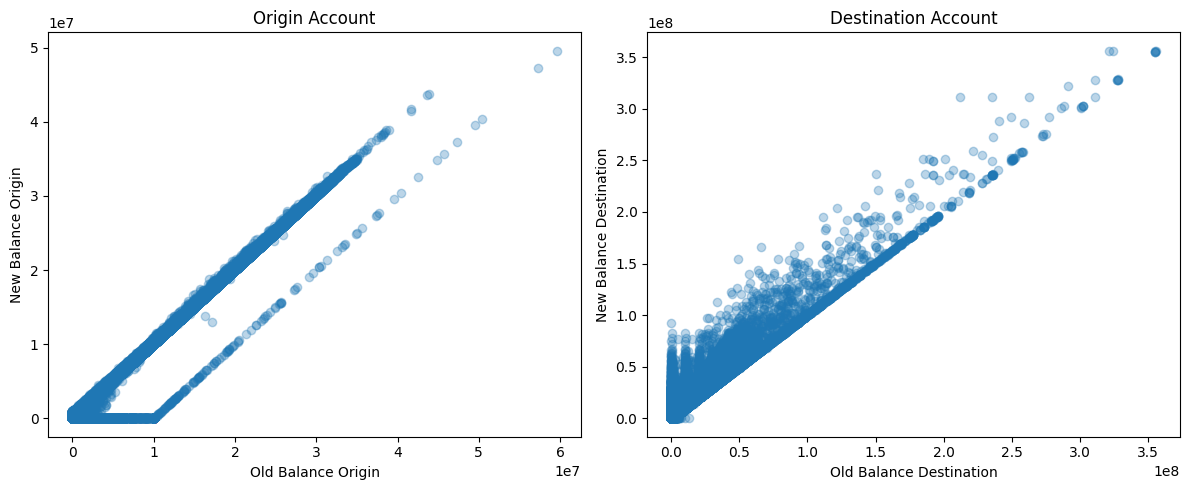

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(data['oldbalanceOrg'], data['newbalanceOrig'], alpha=0.3)
plt.xlabel('Old Balance Origin')
plt.ylabel('New Balance Origin')
plt.title('Origin Account')

plt.subplot(1,2,2)
plt.scatter(data['oldbalanceDest'], data['newbalanceDest'], alpha=0.3)
plt.xlabel('Old Balance Destination')
plt.ylabel('New Balance Destination')
plt.title('Destination Account')

plt.tight_layout()
plt.show()

# INSIGHT:

* Most transactions lie close to the diagonal, indicating that the new balance is generally lower than the old balance after money is debited.

* Transactions where the new balance becomes zero suggest that the sender transferred or withdrew their entire available balance.

* A large number of points at (0, 0) indicate accounts with zero balance before and after the transaction.

* Points that deviate significantly from the expected pattern may represent unusual or potentially fraudulent transactions, especially when the balance does not decrease according to the transaction amount.

* Overall, there is a strong positive relationship between oldbalanceOrg and newbalanceOrig, with the new balance depending on the initial balance and transaction amount.

* The destination account balance generally increases after receiving funds, producing a positive relationship between oldbalanceDest and newbalanceDest.

* Many points occur where the old destination balance is zero, indicating transfers to newly used or previously inactive accounts.

* A noticeable concentration of observations near the origin suggests many accounts have low or zero destination balances.

* Transactions with large increases in destination balance appear as points farther from the origin and represent high-value transfers.
* Any observations where the destination balance does not increase as expected after receiving money may indicate anomalous or suspicious transactions.

# EDA:

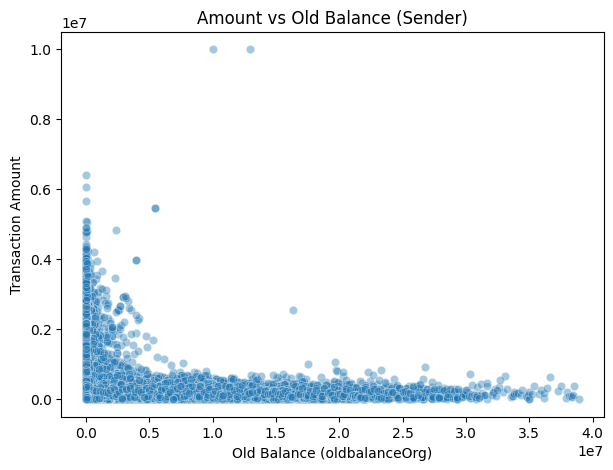

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.scatterplot(data=data,
                x='oldbalanceOrg',
                y='amount',
                alpha=0.4)

plt.title('Amount vs Old Balance (Sender)')
plt.xlabel('Old Balance (oldbalanceOrg)')
plt.ylabel('Transaction Amount')
plt.show()

Insight:

Most transactions have relatively small amounts regardless of the sender's balance.

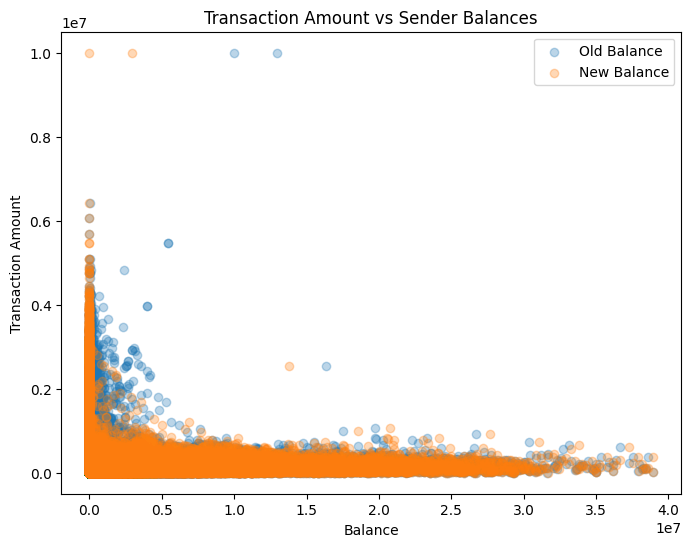

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(data['oldbalanceOrg'], data['amount'],
            alpha=0.3, label='Old Balance')

plt.scatter(data['newbalanceOrig'], data['amount'],
            alpha=0.3, label='New Balance')

plt.xlabel('Balance')
plt.ylabel('Transaction Amount')
plt.title('Transaction Amount vs Sender Balances')
plt.legend()
plt.show()

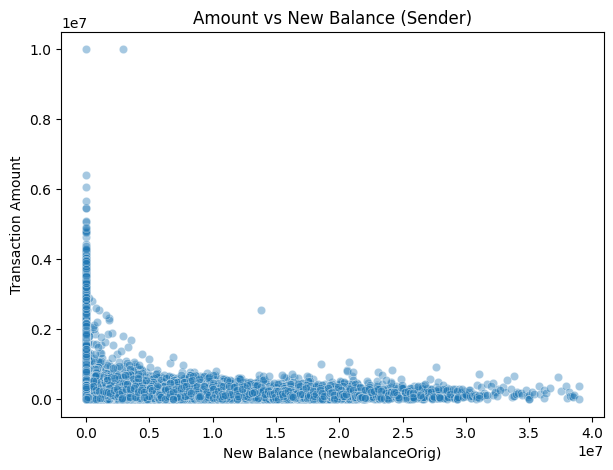

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=data,
                x='newbalanceOrig',
                y='amount',
                alpha=0.4)

plt.title('Amount vs New Balance (Sender)')
plt.xlabel('New Balance (newbalanceOrig)')
plt.ylabel('Transaction Amount')
plt.show()

Insight:

As transaction amount increases, the sender's remaining balance generally decreases



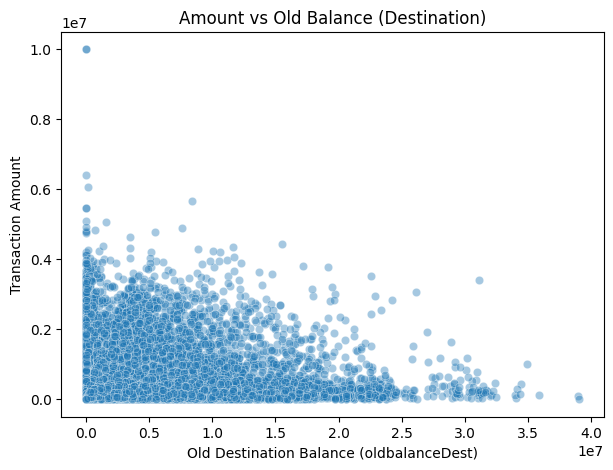

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=data,
    x='oldbalanceDest',
    y='amount',
    alpha=0.4
)

plt.title('Amount vs Old Balance (Destination)')
plt.xlabel('Old Destination Balance (oldbalanceDest)')
plt.ylabel('Transaction Amount')
plt.show()

Insight:

Most transactions involve relatively small amounts regardless of the destination account's initial balance. A few high-value transactions appear as outliers, indicating a weak positive relationship between amount and oldbalanceDest.

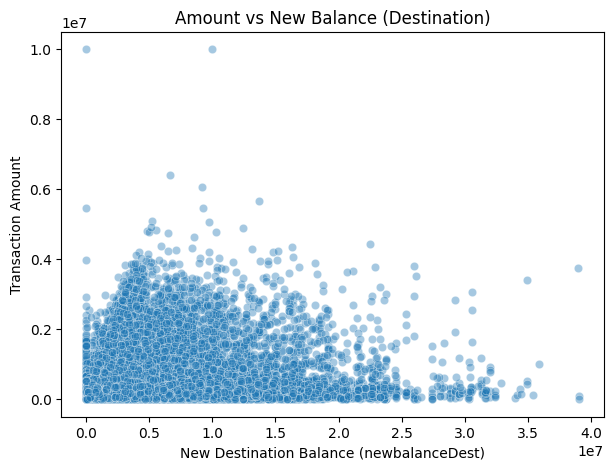

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=data,
    x='newbalanceDest',
    y='amount',
    alpha=0.4
)

plt.title('Amount vs New Balance (Destination)')
plt.xlabel('New Destination Balance (newbalanceDest)')
plt.ylabel('Transaction Amount')
plt.show()

Insight:

As the transaction amount increases, the destination account's balance after the transaction generally increases.

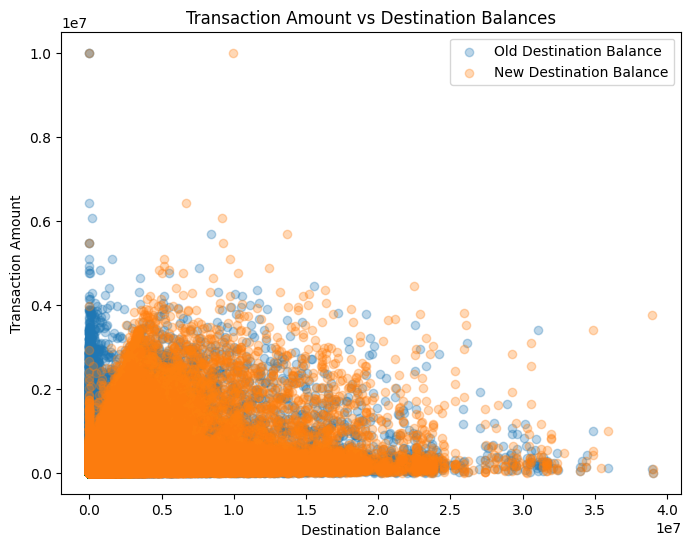

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(data['oldbalanceDest'], data['amount'],
            alpha=0.3, label='Old Destination Balance')

plt.scatter(data['newbalanceDest'], data['amount'],
            alpha=0.3, label='New Destination Balance')

plt.xlabel('Destination Balance')
plt.ylabel('Transaction Amount')
plt.title('Transaction Amount vs Destination Balances')
plt.legend()
plt.show()

insight:

The scatter plots show a weak positive relationship between amount and both oldbalanceDest and newbalanceDest

# UNIVARIENT GRAPH FOR NUMERICAL AND CATEGORICAL DATA :

# NUMERICAL DATA :

# Continuous data :

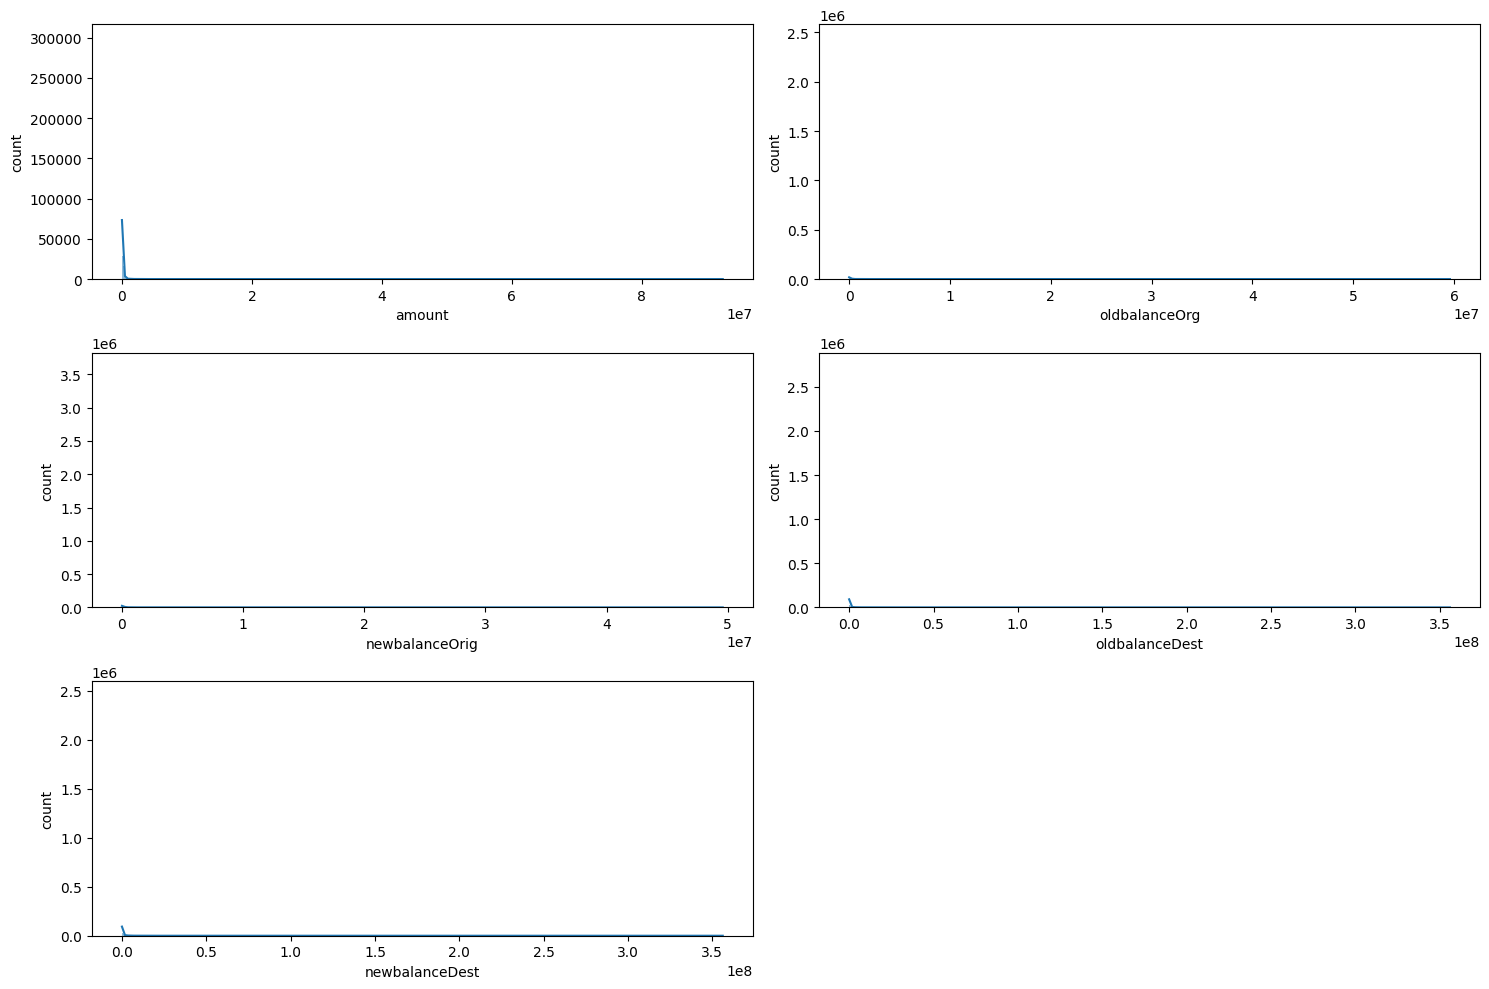

In [ ]:
continuous_cols = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    ]

plt.figure(figsize=(15,10),facecolor='white')
plotnumber=1
for i in continuous_cols:
    if plotnumber<=6:
        ax=plt.subplot(3,2,plotnumber)
        sns.histplot(x=data[i],kde=True)
        plt.xlabel(i,fontsize=10)
        plt.ylabel('count',fontsize=10)
    plotnumber+=1
plt.tight_layout()

INSIGHT:

* Amount is highly right-skewed, with most transactions having relatively small amounts and a small number of very large transactions.

* OldBalanceOrg and NewBalanceOrig are also strongly right-skewed, with most observations concentrated near lower values and a few extreme balances.

* OldBalanceDest and NewBalanceDest show a similar pattern, with most values concentrated near the lower end and some very large values.

* The distributions contain significant outliers, especially in the balance-related variables.

* the numerical features are not normally distributed and are heavily influenced by extreme values.

Discrete data:

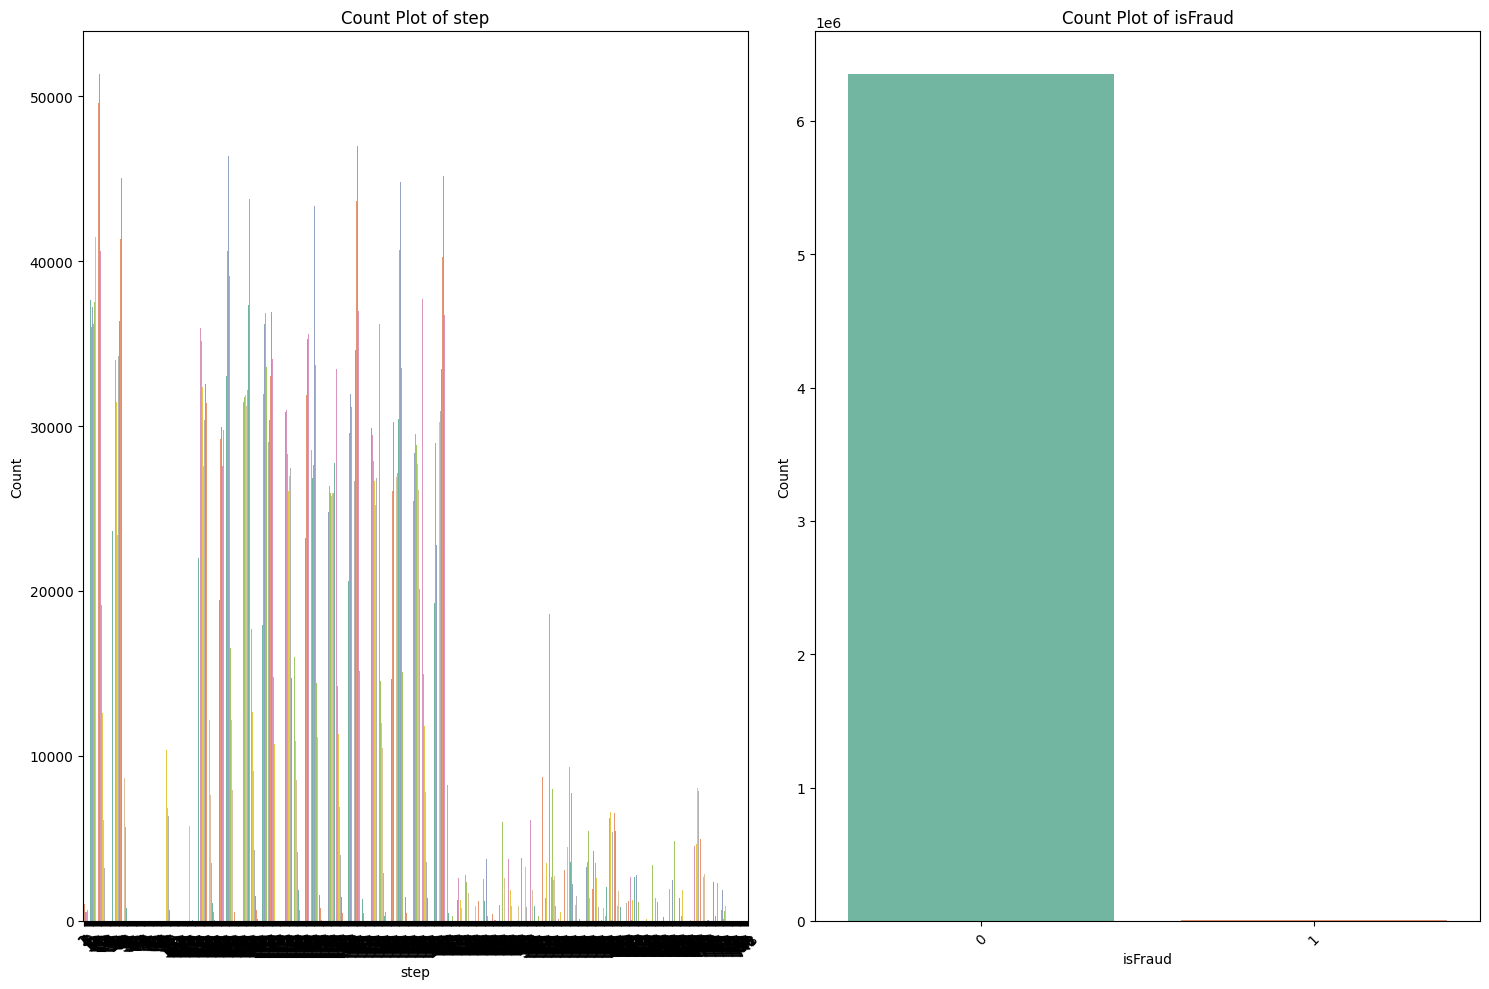

In [ ]:
discrete_col=['step','isFraud']

plt.figure(figsize=(15,10), facecolor='white')

plotnumber = 1

for col in discrete_col:
  if plotnumber <= 2:
    plt.subplot(1,2,plotnumber)
    sns.countplot(data=data, x=col, palette='Set2')

    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

    plotnumber += 1

plt.tight_layout()
plt.show()

INSIGHT:

* The step count plot shows that transaction activity is not evenly distributed across time. Some time steps have much higher transaction volumes than others.

* The transaction volume is particularly high during the earlier and middle periods, while later steps generally show lower activity.

* The isFraud count plot shows a severe class imbalance.
     * Non-fraudulent transactions (isFraud = 0) overwhelmingly dominate the dataset,
     
     * while fraudulent transactions (isFraud = 1) represent only a very small proportion.

* This imbalance is important because a model could achieve high accuracy by simply predicting most transactions as non-fraudulent.

# CATEGORICAL DATA :

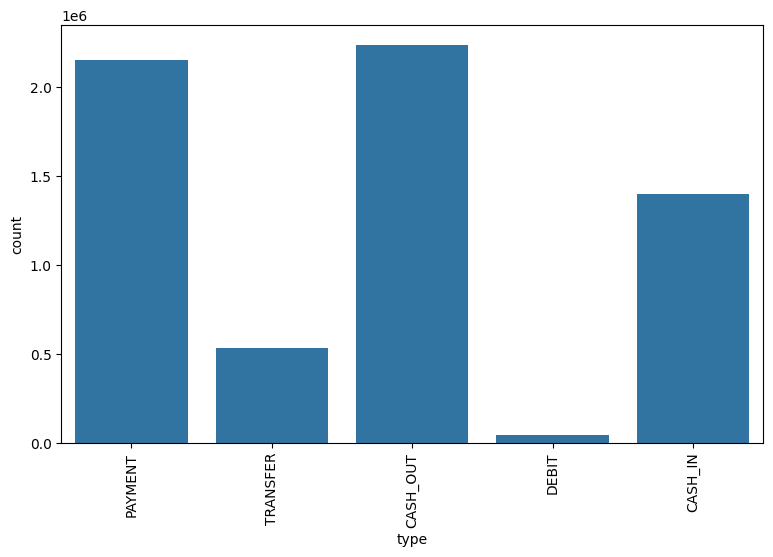

In [ ]:
cat_data=['type']

plt.figure(figsize=(15,10),facecolor='white')
plotnumber=1
for i in cat_data:
    if plotnumber<=4:
        ax=plt.subplot(2,2,plotnumber)
        sns.countplot(x=data[i],data=data)
        plt.xlabel(i,fontsize=10)
        plt.ylabel('count',fontsize=10)
        plt.xticks(rotation=90)
    plotnumber+=1
plt.tight_layout()
plt.show()

INSIGHT:

* CASH_OUT has the highest number of transactions, making it the most frequent transaction type.

* PAYMENT is the second most common transaction type and has a similarly high volume.

* CASH_IN also represents a large proportion of transactions but is lower than CASH_OUT and PAYMENT.

* TRANSFER transactions occur less frequently than the above three types.

* DEBIT has the lowest number of transactions, making it the least common transaction type.

* the dataset is dominated by CASH_OUT, PAYMENT, and CASH_IN transactions, while DEBIT and TRANSFER occur less frequently.

# BIVARIENT GRAPHS FOR NUMERICAL AND CATEGORICAL DATA :

NUMERICAL DATA :

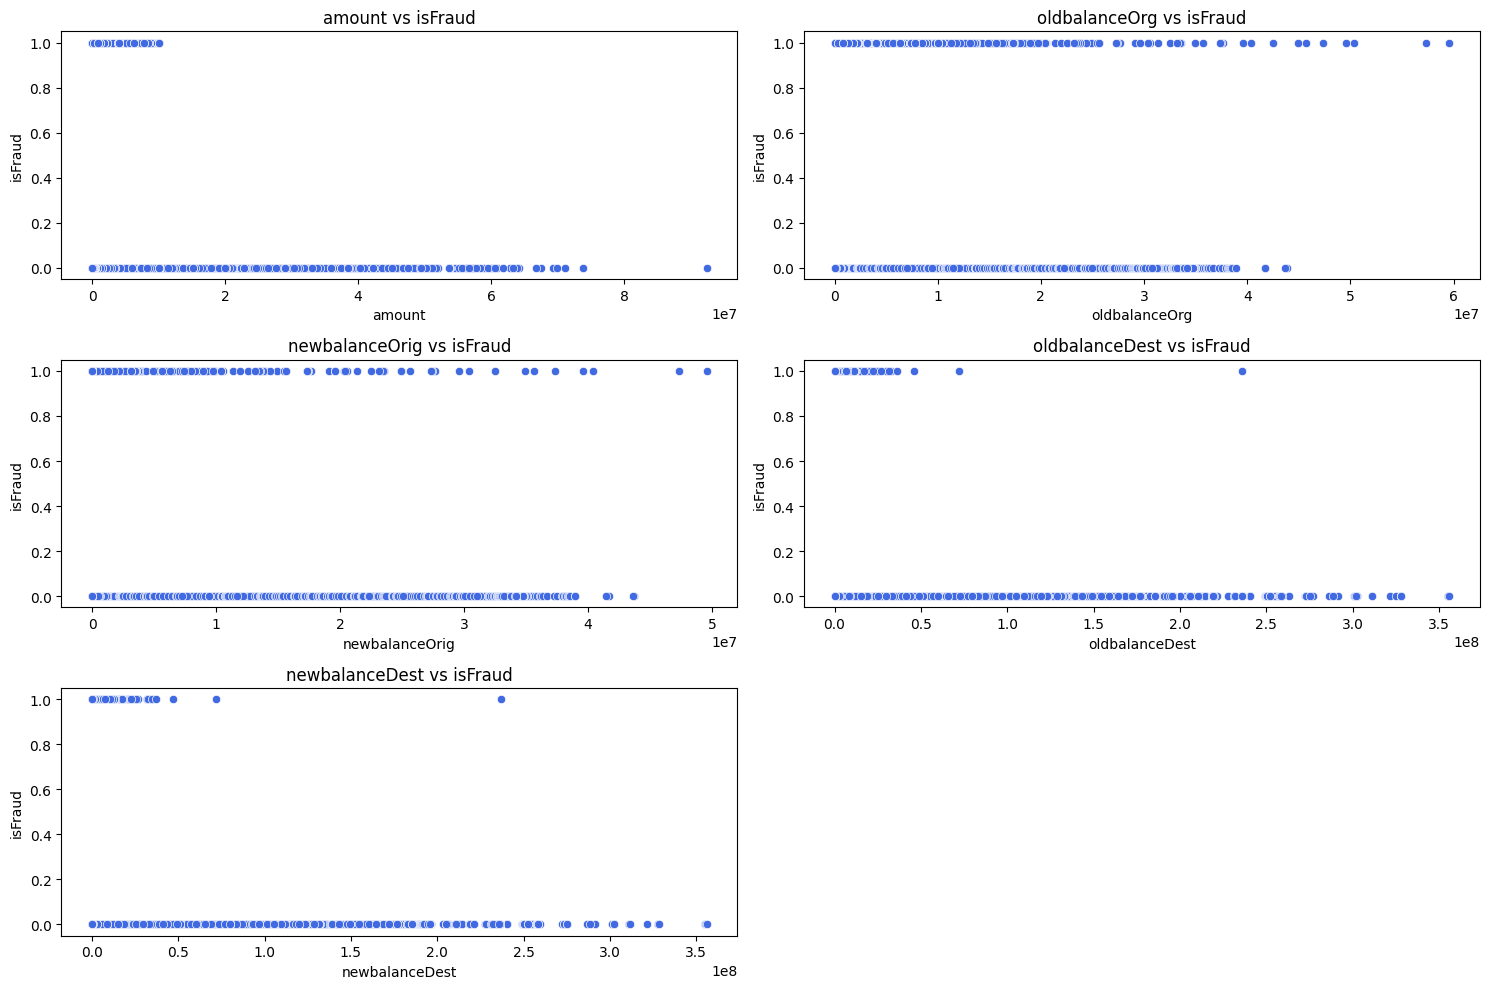

In [ ]:
plt.figure(figsize=(15,10), facecolor='white')

plotnumber = 1

for col in continuous_cols:
  if plotnumber <= 6:
    plt.subplot(3,2, plotnumber)
    sns.scatterplot(data=data, x=col, y='isFraud', color='royalblue')

    plt.title(f'{col} vs isFraud')
    plt.xlabel(col)
    plt.ylabel('isFraud')

    plotnumber += 1

plt.tight_layout()
plt.show()

INSIGHT:

* Amount:
   *  Fraudulent transactions (isFraud = 1) are present across different
   transaction amounts, but most transactions are non-fraudulent. Higher transaction amounts alone do not clearly indicate fraud.

* OldBalanceOrg:
  *  Fraud cases appear mainly within lower-to-moderate balance ranges, with a few higher-value cases. There is no simple linear relationship between the original balance and fraud.

* NewBalanceOrig:
  * Fraudulent transactions are scattered across different new-origin balance values. Therefore, this variable alone does not clearly separate fraudulent and legitimate transactions.

* OldBalanceDest:
  *  Fraud cases are relatively sparse across destination balances. Most transactions are non-fraudulent, so the variable shows limited separation by itself.

* NewBalanceDest:
  *  Similar to oldbalanceDest, fraudulent cases are very limited compared with legitimate transactions and occur across different balance values.

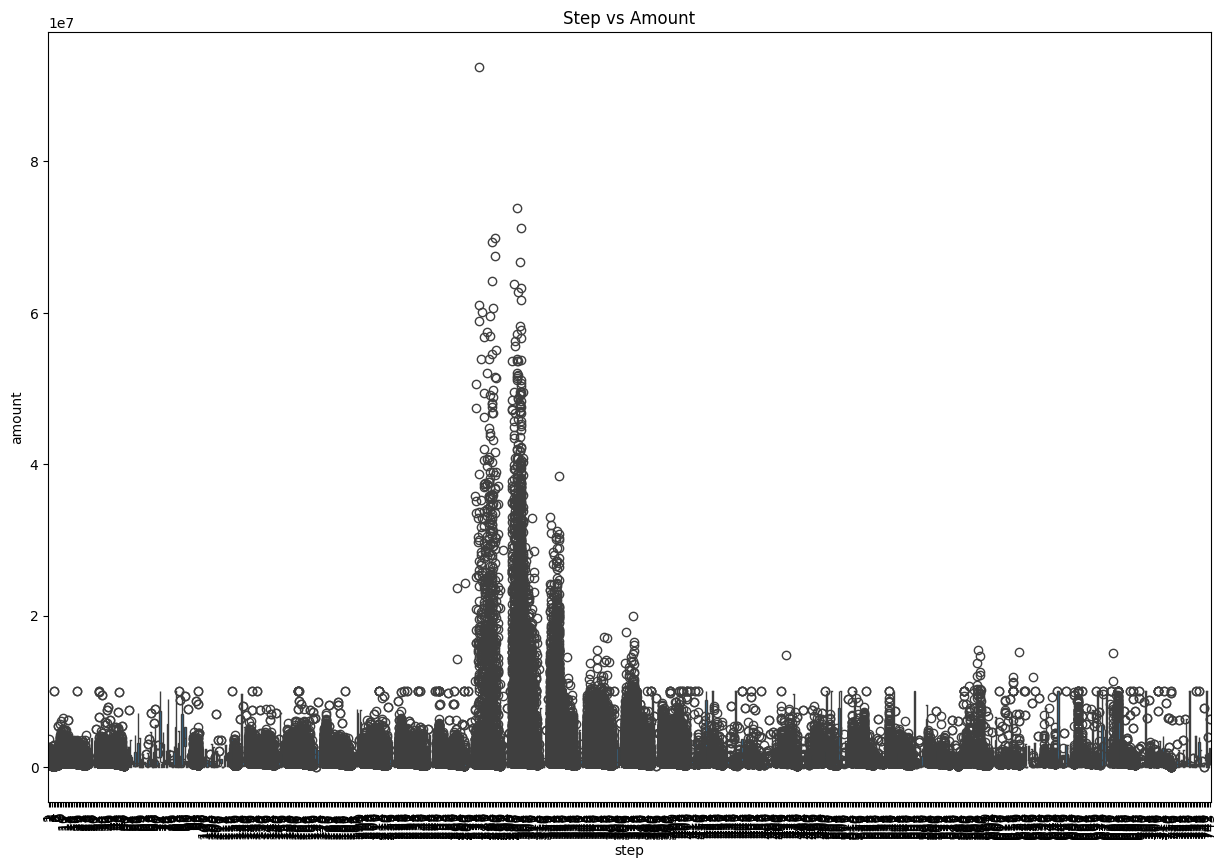

In [ ]:
plt.figure(figsize=(15,10), facecolor='white')

plotnumber = 1

for col in discrete_col:
  if plotnumber <= 2:
    plt.subplot(1,2, plotnumber)
    sns.boxplot(x='step', y='amount', data=data)
    plt.xticks(rotation=90)
    plotnumber += 1

plt.title('Step vs Amount')
plt.show()

INSIGHT:

* The transaction amounts are highly concentrated at lower values, with most transactions occurring below approximately 1 million.

* There are several extreme high-value transactions, reaching around 9 million, indicating strong outliers.

* The highest concentration of large transaction amounts appears around the middle steps of the dataset, rather than being evenly distributed across time.

* As the step increases, transaction amounts do not show a clear linear upward or downward trend.

* Overall, the relationship between step and amount appears weak, but certain time periods contain unusually large transactions that may be useful for fraud detection.

* The large number of outliers also indicates that the amount variable is highly right-skewed.

# CATEGORICAL DATA :

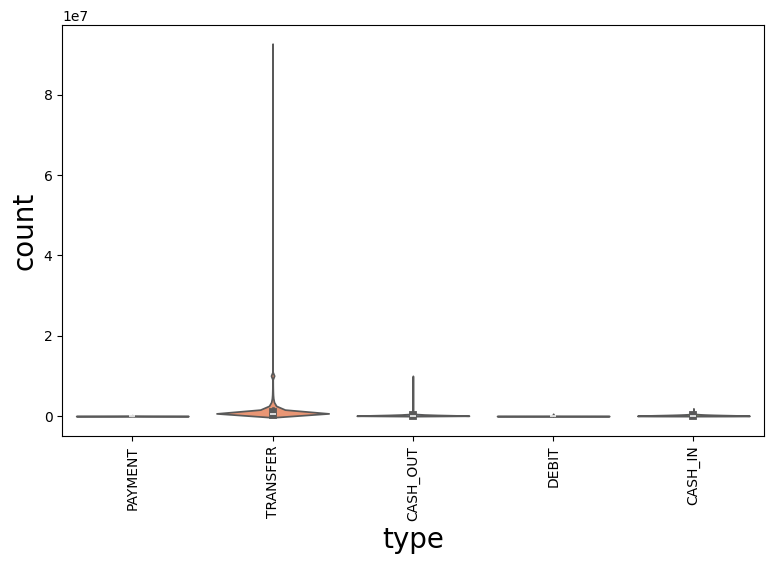

In [ ]:
plt.figure(figsize=(15,10),facecolor='white')
plotnumber=1
for i in cat_data:
    if plotnumber<=4:
        ax=plt.subplot(2,2,plotnumber)
        sns.violinplot(x=data[i], y='amount', data=data,palette='Set2')
        plt.xlabel(i,fontsize=20)
        plt.ylabel('count',fontsize=20)
        plt.xticks(rotation=90)
    plotnumber+=1
plt.tight_layout()

INSIGHT:

* TRANSFER transactions have the highest amount variability, with several extremely large transaction values compared with other transaction types.

* CASH_OUT also shows some high-value transactions, but its distribution is much lower than TRANSFER overall.

* PAYMENT and DEBIT transactions generally have smaller and more concentrated amounts.

* DEBIT shows less variability and does not contribute as strongly to the extreme transaction amounts in the dataset.

* CASH_IN has a wider spread than PAYMENT and DEBIT, with some higher-value transactions.

* The presence of extreme values indicates strong right-skewness and outliers, particularly for TRANSFER transactions.

In [ ]:
cat_data=['type']

In [ ]:
cat_data

['type']

In [ ]:
num_data=['step','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','isFraud']

In [ ]:
num_data

['step',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud']

# Encoding

In [ ]:
for i in cat_data:
    print(i)
    print(data[i].value_counts())
    print('**********************************')


type
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64
**********************************


In [ ]:
data['type'].value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


In [ ]:
data=data.replace({'type':{'CASH_OUT':4,'PAYMENT':3,'CASH_IN':2,'TRANSFER':1,'DEBIT':0}})

In [ ]:
data.head().T

,0,1,2,3,4
step,1,1,1,1,1
type,3,3,1,4,3
amount,9839.64,1864.28,181.0,181.0,11668.14
nameOrig,C1231006815,C1666544295,C1305486145,C840083671,C2048537720
oldbalanceOrg,170136.0,21249.0,181.0,181.0,41554.0
newbalanceOrig,160296.36,19384.72,0.0,0.0,29885.86
nameDest,M1979787155,M2044282225,C553264065,C38997010,M1230701703
oldbalanceDest,0.0,0.0,0.0,21182.0,0.0
newbalanceDest,0.0,0.0,0.0,0.0,0.0
isFraud,0,0,1,1,0


# HEAT MAP

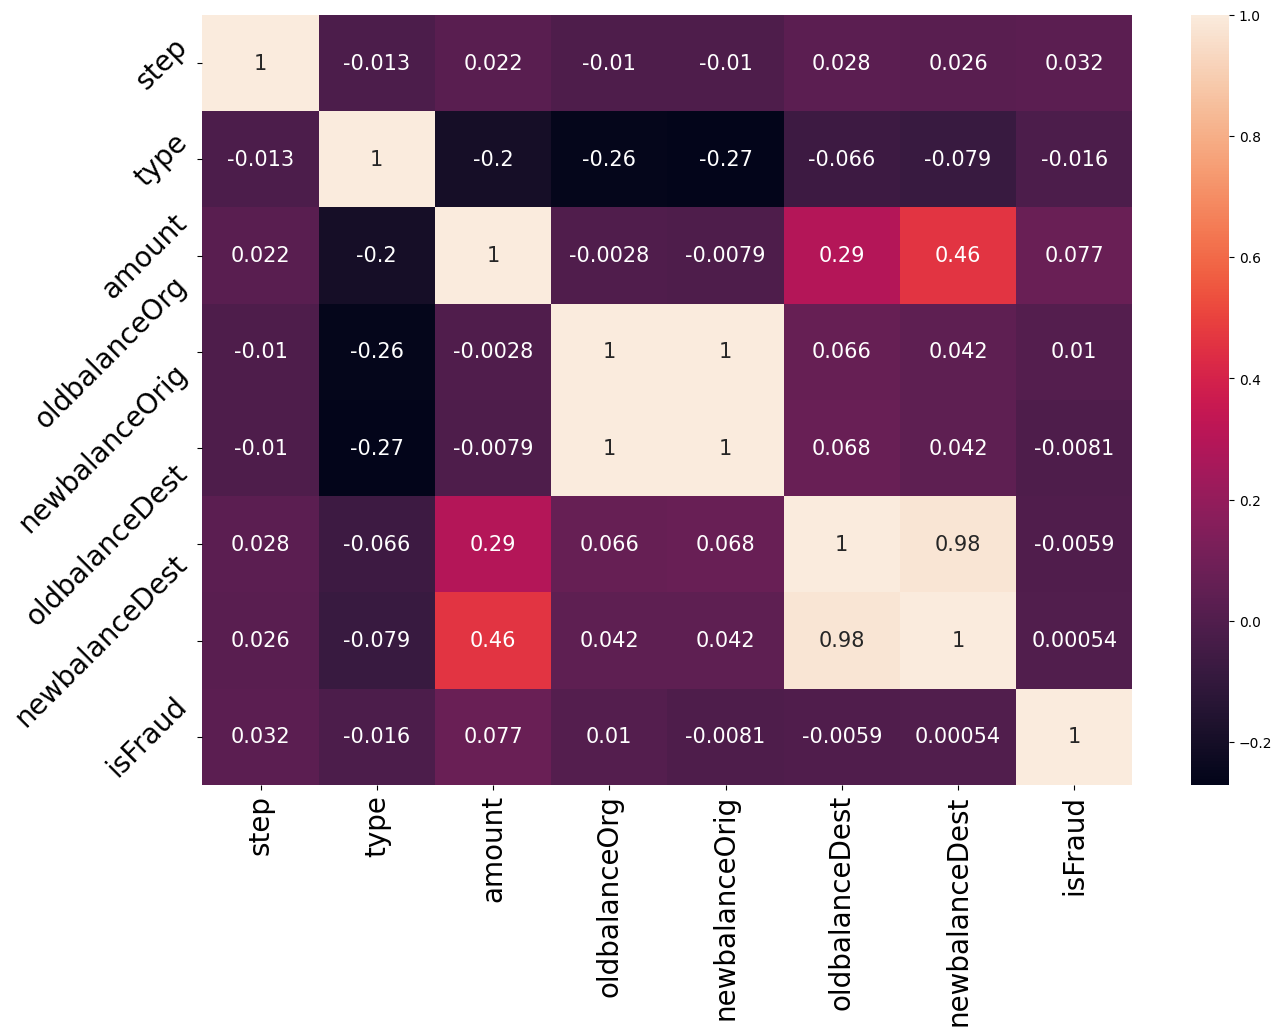

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr(numeric_only=True),annot=True,annot_kws={'size':15})
plt.xticks(fontsize=20,rotation=90)
plt.yticks(fontsize=20,rotation=45)
plt.show()

# Reason:

* newbalanceOrig is highly correlated with oldbalanceOrg.

* newbalanceDest is highly correlated with oldbalanceDest.

* These columns represent the account balances after the transaction, while the corresponding oldbalance... columns represent the balances before the transaction, so they often contain very similar information.

* They contain very similar information (multicollinearity).

* Keeping both may not add much predictive value for some models.

* Removing one can simplify the model and reduce redundancy.

# nameOrig (Origin Account) :

* Represents the sender's account ID.

* C = Customer account
* Characteristics:

     * Almost every value is unique.
     * Very high cardinality (millions of unique IDs).
     * No inherent numerical relationship between IDs.


# nameDest (Destination Account) :

* Represents the receiver's account ID.

    * C123456789 → Customer
    * M1979787155 → Merchant

* C = Customer
* M = Merchant

In [ ]:
data.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

In [ ]:
data.to_csv("fraud_preprocessed1.csv", index=False)

In [ ]:
from google.colab import files

files.download("fraud_preprocessed1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
data=pd.read_csv('/content/fraud_preprocessed1.csv')
data

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,3,9839.64,170136.00,160296.36,0.00,0.00,0
1,1,3,1864.28,21249.00,19384.72,0.00,0.00,0
2,1,1,181.00,181.00,0.00,0.00,0.00,1
3,1,4,181.00,181.00,0.00,21182.00,0.00,1
4,1,3,11668.14,41554.00,29885.86,0.00,0.00,0
...,...,...,...,...,...,...,...,...
6362615,743,4,339682.13,339682.13,0.00,0.00,339682.13,1
6362616,743,1,6311409.28,6311409.28,0.00,0.00,0.00,1
6362617,743,4,6311409.28,6311409.28,0.00,68488.84,6379898.11,1
6362618,743,1,850002.52,850002.52,0.00,0.00,0.00,1


# SPLITING DATA

In [3]:
x=data.drop('isFraud',axis=1)
y=data['isFraud']

In [ ]:
x

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
0,1,3,9839.64,170136.00,160296.36,0.00,0.00
1,1,3,1864.28,21249.00,19384.72,0.00,0.00
2,1,1,181.00,181.00,0.00,0.00,0.00
3,1,4,181.00,181.00,0.00,21182.00,0.00
4,1,3,11668.14,41554.00,29885.86,0.00,0.00
...,...,...,...,...,...,...,...
6362615,743,4,339682.13,339682.13,0.00,0.00,339682.13
6362616,743,1,6311409.28,6311409.28,0.00,0.00,0.00
6362617,743,4,6311409.28,6311409.28,0.00,68488.84,6379898.11
6362618,743,1,850002.52,850002.52,0.00,0.00,0.00


In [ ]:
y

,isFraud
0,0
1,0
2,1
3,1
4,0
...,...
6362615,1
6362616,1
6362617,1
6362618,1


split data for training and testing:

In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
x_train.shape

(5090096, 14)

In [ ]:
x_test.shape

(1272524, 14)

In [ ]:
y_train.shape

(5090096,)

In [ ]:
y_test.shape

(1272524,)

In [ ]:
print(x_train.isnull().sum())
print(x_test.isnull().sum())

step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
dtype: int64
step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
dtype: int64


In [ ]:
data.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,4,9839.64,170136.0,160296.36,0.0,0.0,0.0
1,1,4,1864.28,21249.0,19384.72,0.0,0.0,0.0
2,1,1,181.00,181.0,0.00,0.0,0.0,1.0
3,1,3,181.00,181.0,0.00,21182.0,0.0,1.0
4,1,4,11668.14,41554.0,29885.86,0.0,0.0,0.0


In [ ]:
data

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,10,3,9839.64,170136.00,160296.36,0.00,0.00,0.0
1,10,3,1864.28,21249.00,19384.72,0.00,0.00,0.0
2,10,1,181.00,181.00,0.00,0.00,0.00,0.0
3,10,4,181.00,181.00,0.00,21182.00,0.00,0.0
4,10,3,11668.14,41554.00,29885.86,0.00,0.00,0.0
...,...,...,...,...,...,...,...,...
179009,12,2,200271.90,3896164.44,4096436.33,531167.90,690790.44,0.0
179010,12,2,266616.13,4096436.33,4363052.46,6064698.49,6080565.41,0.0
179011,12,2,194735.24,4363052.46,4557787.70,288407.25,152597.27,0.0
179012,12,2,61212.03,4557787.70,4618999.73,2492638.18,2620615.37,0.0


In [ ]:
print(data['isFraud'].value_counts())

isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [ ]:
print(y_train.value_counts())

isFraud
0    5083526
1       6570
Name: count, dtype: int64


# STANDARD SCALING:



In [5]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# SMOTE :

In [6]:
from collections import Counter
from imblearn.over_sampling import SMOTE
smote=SMOTE()

In [7]:
x_smote,y_smote=smote.fit_resample(x_train_scaled,y_train)
print('actual_ydata',Counter(y_train))

actual_ydata Counter({0: 5083526, 1: 6570})


In [8]:
print('smote_ydata',Counter(y_smote))

smote_ydata Counter({0: 5083526, 1: 5083526})


In [ ]:
print('actual_xdata',(x_smote))

actual_xdata [[-1.60457369  0.05626401 -0.28216888 ... -0.28070627 -0.323308
  -0.33310412]
 [-1.56944154  0.05626401 -0.28724842 ... -0.29245062 -0.323308
  -0.33310412]
 [-0.08686509  1.07571839  0.30093765 ... -0.29245062 -0.17941404
  -0.10167142]
 ...
 [ 1.49394067 -1.98264475  2.95347206 ... -0.29245062 -0.323308
  -0.33310412]
 [ 3.10434634 -1.98264475 -0.1673524  ... -0.29245062 -0.323308
  -0.33310412]
 [-0.66310153  1.07571839  1.12818598 ... -0.29245062  2.10319622
   2.14676043]]


# ** MACHINE LEARNING MODEL BUILDING ** :

LOGISTIC REGRESSION:

In [9]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_smote,y_smote)

LogisticRegression()

In [10]:
y_pred=model.predict(x_test_scaled)

In [ ]:
y_prob=model.predict_proba(x_test_scaled)[:,1]

# EVALUATION

In [11]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,classification_report

In [ ]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[1228557,   42324],
       [    190,    1453]])

In [ ]:
acc=accuracy_score(y_test,y_pred)
acc

0.9665908069317357

In [ ]:
ps=precision_score(y_test,y_pred)
ps

0.03319094501678964

In [ ]:
rs=recall_score(y_test,y_pred)
rs

0.884357881923311

In [ ]:
fs=f1_score(y_test,y_pred)
fs

0.06398062527520916

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98   1270881
           1       0.03      0.88      0.06      1643

    accuracy                           0.97   1272524
   macro avg       0.52      0.93      0.52   1272524
weighted avg       1.00      0.97      0.98   1272524



# ROC - AUC method:

In [ ]:
from sklearn.metrics import roc_curve,auc
false_positive_rate,true_positive_rate,threshholds=roc_curve(y_test,y_pred)


roc_auc_score=auc(false_positive_rate,true_positive_rate)
print(roc_auc_score)

0.92552749995341


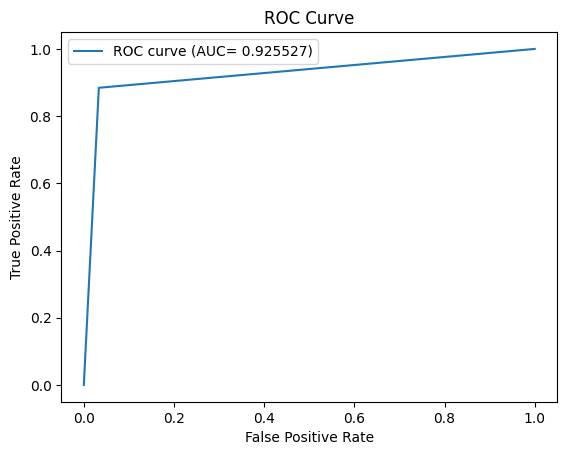

In [ ]:
plt.plot(false_positive_rate,true_positive_rate,label=f'ROC curve (AUC={roc_auc_score: 2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

OPTIMAL K METHOD

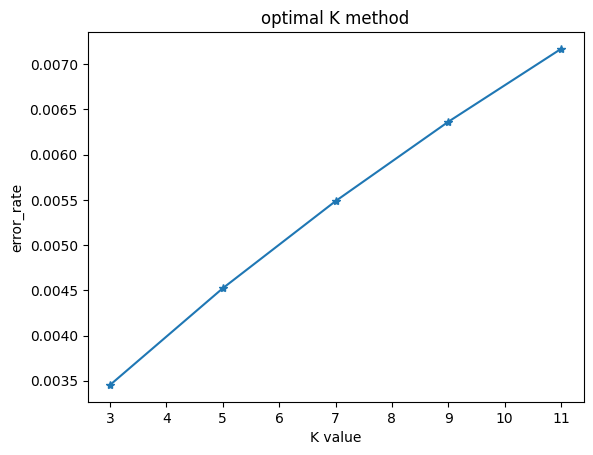

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

error_rate=[]
for i in range(3, 12, 2):
    kmodel=KNeighborsClassifier(n_neighbors=i,n_jobs=-1)
    kmodel.fit(x_smote,y_smote)
    y_pred0=kmodel.predict(x_test_scaled)
    error_rate.append(np.mean(y_pred0!=y_test))
plt.plot(range(3, 12, 2),error_rate,marker='*')
plt.title('optimal K method')
plt.xlabel('K value')
plt.ylabel('error_rate')
plt.show()

KNEIGHBOURS CLASSIFIER:

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

kmodel=KNeighborsClassifier(n_neighbors=3)

In [ ]:
kmodel.fit(x_smote,y_smote)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred1=kmodel.predict(x_test_scaled)

EVALUATE THE MODEL

In [ ]:
cm=confusion_matrix(y_test,y_pred1)
cm

array([[1266780,    4101],
       [    294,    1349]])

In [ ]:
acc=accuracy_score(y_test,y_pred1)
acc

0.9965462340985317

In [ ]:
ps=precision_score(y_test,y_pred1)
ps

0.24752293577981652

In [ ]:
rs=recall_score(y_test,y_pred1)
rs

0.8210590383444918

In [ ]:
fs=f1_score(y_test,y_pred1)
fs

0.3803750176230086

In [ ]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.25      0.82      0.38      1643

    accuracy                           1.00   1272524
   macro avg       0.62      0.91      0.69   1272524
weighted avg       1.00      1.00      1.00   1272524



RANDOM FOREST CLASSIFIER:

In [ ]:
from sklearn.ensemble import RandomForestClassifier
Rmodel=RandomForestClassifier(n_estimators=20,
    max_depth=10,
    n_jobs=-1,
    random_state=42)
Rmodel.fit(x_smote,y_smote)

RandomForestClassifier(max_depth=10, n_estimators=20, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred3=Rmodel.predict(x_test_scaled)


EVALUATE THE MODEL

In [ ]:
cm=confusion_matrix(y_test,y_pred3)
cm

array([[1246388,   24493],
       [     16,    1627]])

In [ ]:
acc=accuracy_score(y_test,y_pred3)
acc

0.98073985245072

In [ ]:
ps=precision_score(y_test,y_pred3)
ps

0.06228943338437978

In [ ]:
rs=recall_score(y_test,y_pred3)
rs

0.9902617163724894

In [ ]:
fs=f1_score(y_test,y_pred3)
fs

0.11720635378021108

In [ ]:
print(classification_report(y_test,y_pred3))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.06      0.99      0.12      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.99      0.55   1272524
weighted avg       1.00      0.98      0.99   1272524



DECISION TREE CLASSIFIER:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
Dmodel=DecisionTreeClassifier( max_depth=8,
    min_samples_leaf=10,
    random_state=42
)
Dmodel.fit(x_smote,y_smote)

DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=42)

In [ ]:
y_pred4=Dmodel.predict(x_test_scaled)

EVALUATE THE MODEL

In [ ]:
cm=confusion_matrix(y_test,y_pred4)
cm

array([[1256229,   14652],
       [      8,    1635]])

In [ ]:
acc=accuracy_score(y_test,y_pred4)
acc

0.9884795885971502

In [ ]:
ps=precision_score(y_test,y_pred4)
ps

0.10038681156750782

In [ ]:
rs=recall_score(y_test,y_pred4)
rs

0.9951308581862447

In [ ]:
fs=f1_score(y_test,y_pred4)
fs

0.18237590630228667

In [ ]:
print(classification_report(y_test,y_pred4))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1270881
           1       0.10      1.00      0.18      1643

    accuracy                           0.99   1272524
   macro avg       0.55      0.99      0.59   1272524
weighted avg       1.00      0.99      0.99   1272524



GRADIENT BOOSTING CLASSIFIER:

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
gb=HistGradientBoostingClassifier(max_iter=120)
gb.fit(x_smote,y_smote)

HistGradientBoostingClassifier(max_iter=120)

In [ ]:
y_pred6=gb.predict(x_test_scaled)

EVALUATE THE MODEL

In [ ]:
cm=confusion_matrix(y_test,y_pred6)
cm

array([[1263710,    7171],
       [     11,    1632]])

In [ ]:
acc=accuracy_score(y_test,y_pred6)
acc

0.9943560985883174

In [ ]:
ps=precision_score(y_test,y_pred6)
ps

0.1853913438600477

In [ ]:
rs=recall_score(y_test,y_pred6)
rs

0.9933049300060864

In [ ]:
fs=f1_score(y_test,y_pred6)
fs

0.31246410109132683

In [ ]:
print(classification_report(y_test,y_pred6))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.19      0.99      0.31      1643

    accuracy                           0.99   1272524
   macro avg       0.59      0.99      0.65   1272524
weighted avg       1.00      0.99      1.00   1272524



XGB CLASSIFIER:

In [ ]:
from xgboost import XGBClassifier
Xmodel=XGBClassifier()
Xmodel.fit(x_smote,y_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred7=Xmodel.predict(x_test_scaled)

EVALUATION THE MODEL



In [ ]:
cm=confusion_matrix(y_test,y_pred7)
cm

array([[1267966,    2915],
       [      9,    1634]])

In [ ]:
acc=accuracy_score(y_test,y_pred7)
acc

0.9977022044377944

In [ ]:
ps=precision_score(y_test,y_pred7)
ps

0.359199824137173

In [ ]:
rs=recall_score(y_test,y_pred7)
rs

0.9945222154595252

In [ ]:
fs=f1_score(y_test,y_pred7)
fs

0.5277777777777778

In [ ]:
print(classification_report(y_test,y_pred7))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.36      0.99      0.53      1643

    accuracy                           1.00   1272524
   macro avg       0.68      1.00      0.76   1272524
weighted avg       1.00      1.00      1.00   1272524



| Model                 |    F1 Score |
| --------------------- | ----------: |
| **XGBoost**           | **0.52777** |
 | **KNN**               | **0.38037** |
 | **Gradient Boosting** | **0.31246** |
 | Decision Tree         |     **0.18237** |
 | Random Forest         |     **0.11720** |
 | Logistic Regression    |     **0.06398** |

BEST MODEL FOR COMPARISON AND TUNING :

| **Model**                 | **F1-Score** |
| ------------------------- | -----------: |
| XGBoost	          |   **0.52777**
| K-Nearest Neighbors (KNN)  |  **0.38037** |
| Gradient Boosting	|  **0.31246**|

XGB CLASSIFIER:

In [ ]:
from xgboost import XGBClassifier
xmodel=XGBClassifier()
xmodel.fit(x_smote,y_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xy_pred=xmodel.predict(x_test_scaled)

EVALUATION THE MODEL



In [ ]:
cm=confusion_matrix(y_test,xy_pred)
cm

array([[1267966,    2915],
       [      9,    1634]])

In [ ]:
acc=accuracy_score(y_test,xy_pred)
acc

0.9977022044377944

In [ ]:
ps=precision_score(y_test,xy_pred)
ps

0.359199824137173

In [ ]:
rs=recall_score(y_test,xy_pred)
rs

0.9945222154595252

In [ ]:
fs=f1_score(y_test,xy_pred)
fs

0.5277777777777778

In [ ]:
print(classification_report(y_test,xy_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.36      0.99      0.53      1643

    accuracy                           1.00   1272524
   macro avg       0.68      1.00      0.76   1272524
weighted avg       1.00      1.00      1.00   1272524



HYPER PARAMETER TUNING:

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist={'gamma':[0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4,200],
            'learning_rate':[0.01,0.03,0.06,0.1,0.15,0.2,0.25,0.300000012,0.4,0.5,0.6,0.7],
            'max_depth':[5,6,7,8,9,10,11,12,13,14],
            'n_estimators':[50,65,80,100,115,130,150],
            'reg_alpha':[0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4,200],
            'reg_lambda':[0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4,200]}

XGB=XGBClassifier()
rcv=RandomizedSearchCV(estimator=XGB,scoring='f1',param_distributions=param_dist,n_iter=100,cv=3,verbose=2,random_state=42)
rcv.fit(x_smote,y_smote)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END gamma=0, learning_rate=0.6, max_depth=8, n_estimators=50, reg_alpha=12.8, reg_lambda=1.6; total time=  28.8s
[CV] END gamma=0, learning_rate=0.6, max_depth=8, n_estimators=50, reg_alpha=12.8, reg_lambda=1.6; total time=  30.3s
[CV] END gamma=0, learning_rate=0.6, max_depth=8, n_estimators=50, reg_alpha=12.8, reg_lambda=1.6; total time=  29.1s
[CV] END gamma=0.8, learning_rate=0.4, max_depth=12, n_estimators=80, reg_alpha=0.8, reg_lambda=0.8; total time=  42.1s
[CV] END gamma=0.8, learning_rate=0.4, max_depth=12, n_estimators=80, reg_alpha=0.8, reg_lambda=0.8; total time=  40.4s
[CV] END gamma=0.8, learning_rate=0.4, max_depth=12, n_estimators=80, reg_alpha=0.8, reg_lambda=0.8; total time=  41.4s
[CV] END gamma=0, learning_rate=0.7, max_depth=6, n_estimators=100, reg_alpha=12.8, reg_lambda=12.8; total time=  44.4s
[CV] END gamma=0, learning_rate=0.7, max_depth=6, n_estimators=100, reg_alpha=12.8, reg_lambda=12.8; to

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                                  102.4, 200],
                                        'learning_rate': [0.01, 0.03, 0.06, 0.1,
                                                          0.15, 0.2, 0.25,
                                                          0.300000012, 0.4, 0.5,
                                                          0.6, 0.7],
                                        'max_depth': [5, 6, 7, 8, 9, 10, 11, 12,
                                                      13, 14],
                                        'n_estimators': [50, 65, 80, 100, 115,
                                                         130, 150],
                                        'reg_alpha': [0, 0.1, 0.2, 0.4, 0.8,
                                                      1.6, 3.2, 6.4, 12.8, 25.6,
                                                      51.2, 102.4, 200],
                                        'reg_lambda': [0, 0.1, 0.2, 0.4, 0.8,
                                                       1.6, 3.2, 6.4, 12.8,
                                                       25.6, 51.2, 102.4,
                                                       200]},
                   random_state=42, scoring='f1', verbose=2)

In [ ]:
print(rcv.best_params_)

{'reg_lambda': 3.2, 'reg_alpha': 3.2, 'n_estimators': 130, 'max_depth': 14, 'learning_rate': 0.6, 'gamma': 0.1}


In [ ]:
model=XGBClassifier(reg_lambda=3.2,reg_alpha=3.2,n_estimators=130,max_depth=14,learning_rate=0.6,gamma=0.1)
model.fit(x_smote,y_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.6, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=14,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=130,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xy_predict=model.predict(x_test_scaled)

EVALUATION THE MODEL



In [ ]:
cm=confusion_matrix(y_test,xy_predict)
cm

array([[1269829,    1052],
       [     42,    1601]])

In [ ]:
acc=accuracy_score(y_test,xy_predict)
acc

0.9991402912636618

In [ ]:
ps=precision_score(y_test,xy_predict)
ps

0.6034677723332077

In [ ]:
rs=recall_score(y_test,xy_predict)
rs

0.9744370054777846

In [ ]:
fs=f1_score(y_test,xy_predict)
fs

0.7453445065176909

In [ ]:
print(classification_report(y_test,xy_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.60      0.97      0.75      1643

    accuracy                           1.00   1272524
   macro avg       0.80      0.99      0.87   1272524
weighted avg       1.00      1.00      1.00   1272524



KNEIGHBOURS CLASSIFIER :

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
knn.fit(x_smote, y_smote)

KNeighborsClassifier(n_jobs=-1, n_neighbors=3)

In [10]:
y_predd=knn.predict(x_test_scaled)

EVALUATION THE MODEL

In [13]:
cm=confusion_matrix(y_test,y_predd)
cm

array([[1266783,    4098],
       [    294,    1349]])

In [14]:
acc=accuracy_score(y_test,y_predd)
acc

0.9965485916179184

In [15]:
ps=precision_score(y_test,y_predd)
ps

0.24765926197907104

In [16]:
rs=recall_score(y_test,y_predd)
rs

0.8210590383444918

In [17]:
fs=f1_score(y_test,y_predd)
fs

0.38053596614950636

In [18]:
print(classification_report(y_test,y_predd))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.25      0.82      0.38      1643

    accuracy                           1.00   1272524
   macro avg       0.62      0.91      0.69   1272524
weighted avg       1.00      1.00      1.00   1272524



HYPER PARAMETER TUNING

In [41]:
from sklearn.model_selection import RandomizedSearchCV

knn = KNeighborsClassifier(n_jobs=-1)

param_dist = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

random_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_dist,
    n_iter=3,
    cv=2,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(x_smote,y_smote)


Fitting 2 folds for each of 3 candidates, totalling 6 fits


RandomizedSearchCV(cv=2, estimator=KNeighborsClassifier(n_jobs=-1), n_iter=3,
                   n_jobs=-1,
                   param_distributions={'n_neighbors': [3, 5, 7], 'p': [1, 2],
                                        'weights': ['uniform', 'distance']},
                   random_state=42, scoring='f1', verbose=1)

In [42]:
print(f'best_parameters:{random_search.best_params_}')

best_parameters:{'weights': 'uniform', 'p': 1, 'n_neighbors': 3}


In [43]:
knn_model = KNeighborsClassifier(
    n_neighbors=3,
    weights='uniform',
    p=1,
)

knn_model.fit(x_smote,y_smote)

KNeighborsClassifier(n_neighbors=3, p=1)

In [44]:
y_predict=knn_model.predict(x_test_scaled)

EVALUATION THE MODEL

In [45]:
cm=confusion_matrix(y_test,y_predict)
cm

array([[1266809,    4072],
       [    261,    1382]])

In [46]:
acc=accuracy_score(y_test,y_predict)
acc

0.9965949561658562

In [47]:
ps=precision_score(y_test,y_predict)
ps

0.2533920058672534

In [48]:
rs=recall_score(y_test,y_predict)
rs

0.8411442483262325

In [49]:
fs=f1_score(y_test,y_predict)
fs

0.38946033535296604

In [50]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.25      0.84      0.39      1643

    accuracy                           1.00   1272524
   macro avg       0.63      0.92      0.69   1272524
weighted avg       1.00      1.00      1.00   1272524



HISTGRADIENT BOOSTING CLASSIFIER:

In [12]:
from sklearn.ensemble import HistGradientBoostingClassifier
gb=HistGradientBoostingClassifier(max_iter=120)
gb.fit(x_smote,y_smote)

HistGradientBoostingClassifier(max_iter=120)

In [13]:
y_predg=gb.predict(x_test_scaled)

EVALUATION THE MODEL




In [14]:
cm=confusion_matrix(y_test,y_predg)
cm

array([[1263868,    7013],
       [      9,    1634]])

In [15]:
acc=accuracy_score(y_test,y_predg)
acc

0.9944818329556063

In [16]:
ps=precision_score(y_test,y_predg)
ps

0.1889672718862033

In [17]:
rs=recall_score(y_test,y_predg)
rs

0.9945222154595252

In [18]:
fs=f1_score(y_test,y_predg)
fs

0.31758989310009716

In [19]:
print(classification_report(y_test,y_predg))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.19      0.99      0.32      1643

    accuracy                           0.99   1272524
   macro avg       0.59      0.99      0.66   1272524
weighted avg       1.00      0.99      1.00   1272524



HYPER PARAMETER TUNING:

In [20]:
from sklearn.model_selection import RandomizedSearchCV
gb = HistGradientBoostingClassifier(random_state=42)

param_dist = {
    'max_iter': [50,100],
    'learning_rate': [0.05, 0.1],
    'min_samples_leaf':[20,50],
    'max_depth': [2,3],
    'l2_regularization': [0, 1]
}

random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    n_iter=3,
    cv=2,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(x_smote,y_smote)

Fitting 2 folds for each of 3 candidates, totalling 6 fits


RandomizedSearchCV(cv=2,
                   estimator=HistGradientBoostingClassifier(random_state=42),
                   n_iter=3, n_jobs=-1,
                   param_distributions={'l2_regularization': [0, 1],
                                        'learning_rate': [0.05, 0.1],
                                        'max_depth': [2, 3],
                                        'max_iter': [50, 100],
                                        'min_samples_leaf': [20, 50]},
                   random_state=42, scoring='f1', verbose=1)

In [21]:
print(random_search.best_params_)

{'min_samples_leaf': 50, 'max_iter': 100, 'max_depth': 3, 'learning_rate': 0.1, 'l2_regularization': 0}


In [24]:
model_gb=HistGradientBoostingClassifier(max_iter=100,learning_rate=0.1,max_depth=3,min_samples_leaf=50,l2_regularization=0)
model_gb.fit(x_smote,y_smote)

HistGradientBoostingClassifier(l2_regularization=0, max_depth=3,
                               min_samples_leaf=50)

In [25]:
y_predictg =model_gb.predict(x_test_scaled)

EVALUATION THE MODEL



In [26]:
cm=confusion_matrix(y_test,y_predictg)
cm

array([[1244686,   26195],
       [     13,    1630]])

In [27]:
acc=accuracy_score(y_test,y_predictg)
acc

0.9794047106380704

In [28]:
ps=precision_score(y_test,y_predictg)
ps

0.058580413297394426

In [29]:
rs=recall_score(y_test,y_predictg)
rs

0.9920876445526476

In [30]:
fs=f1_score(y_test,y_predictg)
fs

0.11062847834939596

In [31]:
print(classification_report(y_test,y_predictg))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.06      0.99      0.11      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.99      0.55   1272524
weighted avg       1.00      0.98      0.99   1272524



Based on the F1 scores after hyperparameter tuning,
   
  *  XGBoost is the best model.


  | Model                 |  (f1 score)Before |  (f1 score) After | Improvement |
| --------------------- | ------: | ------: | ------------------: |
| XGBoost               | 0.52777 | 0.74534 |        **+0.21757** |
| KNN                   | 0.38053 | 0.38946 |        **+0.00893** |
| HistGradient Boosting | 0.31758 | 0.11062 |        **-0.20696** |



### SUMMARY

* **XGBoost** achieved the highest F1 score of **0.74534** after tuning, making it the **best-performing model** for the fraud detection task.

* **KNeighborsClassifier** showed a slight improvement after tuning, increasing from **0.38053 to 0.38946**. However, it still performed worse than XGBoost.

* **HistGradientBoostingClassifier** performed worse after tuning, with its F1 score decreasing from **0.31758 to 0.11062**.

* Overall, **XGBoost is the best model** among the three models based on the highest F1 score after tuning.

# Key Factors Predicting Fraud :

* Transaction Type  :
     
  * Fraud mainly occurs in TRANSFER and CASH_OUT transactions.
  
* Transaction Amount :  

  * Fraudulent transactions often involve relatively large amounts.    

* oldbalanceOrg  :

   * High sender balance before the transaction is common in fraud.     

* newbalanceOrig :  
  * Fraudsters often reduce the sender balance to nearly zero.         

* oldbalanceDest :  
   * Helps identify unusual recipient account behavior.                 

* newbalanceDest :
  *  Large balance increases after transfers may indicate fraud.        

* Step (Time)  :

   * Fraud may occur more frequently during specific periods.           
